# Inciso 9. Generación de mapas predictivos

Este notebook aplica el Random Forest seleccionado en el inciso 8 para estimar la probabilidad de alta presencia de cianobacteria en cada observación, reconstruir las predicciones sobre la cuadrícula de 1 km y analizar espacialmente aciertos y errores en los lagos Atitlán y Amatitlán.

## Criterio de evaluación

Se generan dos tipos de predicción:

- **Modelo final:** se entrena con todos los datos y produce las probabilidades que se usarían operacionalmente en los mapas.
- **Predicciones espaciales fuera de muestra:** se obtienen con `GroupKFold`, manteniendo cada bloque completamente fuera del entrenamiento de su fold. Estas predicciones se usan para localizar falsos positivos, falsos negativos y regiones difíciles sin el optimismo de evaluar al modelo sobre sus propios datos de entrenamiento.

La escala se mantiene fija entre lagos y fechas: muy baja `[0, 0.25)`, baja `[0.25, 0.50)`, alta `[0.50, 0.75)` y muy alta `[0.75, 1]`.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import GroupKFold

sns.set_theme(style='white', context='notebook')
RANDOM_STATE = 42
CRS_MAPA = 'EPSG:32615'

In [2]:
RUTA_DATOS = Path('datos_predictores_bloques.csv')
RUTAS_REFERENCIA = {
    'amatitlan': Path('datos_lagos/amatitlan.geojson'),
    'atitlan': Path('datos_lagos/atitlan.geojson')
}

if not RUTA_DATOS.exists():
    raise FileNotFoundError(f'No se encontró {RUTA_DATOS.resolve()}')
if not all(ruta.exists() for ruta in RUTAS_REFERENCIA.values()):
    raise FileNotFoundError('No se encontraron las referencias GeoJSON de ambos lagos.')

df = pd.read_csv(RUTA_DATOS, parse_dates=['fecha'])
referencias = {
    lago: gpd.read_file(ruta).to_crs(CRS_MAPA)
    for lago, ruta in RUTAS_REFERENCIA.items()
}

resumen_datos = (df.groupby('lago')
                 .agg(observaciones=('lago', 'size'),
                      bloques=('id_bloque', 'nunique'),
                      fechas=('fecha', 'nunique'),
                      primera_fecha=('fecha', 'min'),
                      ultima_fecha=('fecha', 'max'),
                      prevalencia_alta=('alta_cianobacteria', 'mean')))
display(resumen_datos.style.format({'prevalencia_alta': '{:.1%}'}))

,observaciones,bloques,fechas,primera_fecha,ultima_fecha,prevalencia_alta
lago,,,,,,
amatitlan,1650,150,11,2025-01-28 00:00:00,2026-06-19 00:00:00,30.5%
atitlan,5544,504,11,2025-01-18 00:00:00,2026-07-22 00:00:00,51.2%


### Alcance espacial de los datos

Las coordenadas `x` y `y` están en WGS 84 / UTM zona 15N (`EPSG:32615`) y representan centros de bloques de 1 km. Los GeoJSON del repositorio son **envolventes rectangulares de adquisición**, no polígonos detallados de la ribera; por ello solo se dibujan como referencia de extensión. Los mapas representan todas las observaciones usadas por los modelos anteriores, incluidos bloques mixtos de agua y orilla. Para un producto operativo sería necesario recortar con un contorno hidrográfico preciso y una máscara de agua validada.

## 9.1. Probabilidad de alta presencia para cada observación

Se mantienen los predictores y los hiperparámetros del mejor modelo del inciso 8. `ndci`, `chl_a_estimada`, B04 y B05 continúan excluidos para evitar fuga directa. Como se indicó en el inciso 8, NDVI y las proporciones derivadas de este comparten indirectamente B04 con la respuesta; se conservan para reproducir el modelo seleccionado, pero esta dependencia limita la interpretación.

In [3]:
PREDICTORES = [
    'bloque_fila', 'bloque_columna', 'x', 'y', 'b03', 'b08',
    'ndvi', 'ndwi', 'proporcion_agua', 'proporcion_tierra',
    'proporcion_otro', 'pixeles_validos'
]
OBJETIVO = 'alta_cianobacteria'

if df[PREDICTORES + [OBJETIVO]].isna().any().any():
    raise ValueError('Hay valores faltantes en las variables requeridas.')

X = df[PREDICTORES].copy()
y = df[OBJETIVO].astype(int)
groups = df['id_bloque']

modelo_base = RandomForestClassifier(
    n_estimators=200, max_depth=7, max_features='sqrt',
    min_samples_leaf=1, min_samples_split=5,
    n_jobs=-1, random_state=0
)
modelo_final = clone(modelo_base).fit(X, y)
df['probabilidad_alta'] = modelo_final.predict_proba(X)[:, 1]
df['prediccion_final'] = (df['probabilidad_alta'] >= 0.50).astype('int8')
df['nivel_probabilidad'] = pd.cut(
    df['probabilidad_alta'], bins=[0, 0.25, 0.50, 0.75, 1.000001],
    labels=['Muy baja', 'Baja', 'Alta', 'Muy alta'],
    include_lowest=True, right=False
)

display(df[['lago', 'fecha', 'id_bloque', 'x', 'y',
            'probabilidad_alta', 'nivel_probabilidad']].head())
display(pd.crosstab(df['lago'], df['nivel_probabilidad'], normalize='index').style.format('{:.1%}'))

,lago,fecha,id_bloque,x,y,probabilidad_alta,nivel_probabilidad
0,amatitlan,2025-01-28,amatitlan_1594_754,754500.0,1594500.0,0.011646,Muy baja
1,amatitlan,2025-01-28,amatitlan_1594_755,755500.0,1594500.0,0.066122,Muy baja
2,amatitlan,2025-01-28,amatitlan_1594_756,756500.0,1594500.0,0.484755,Baja
3,amatitlan,2025-01-28,amatitlan_1594_757,757500.0,1594500.0,0.411225,Baja
4,amatitlan,2025-01-28,amatitlan_1594_758,758500.0,1594500.0,0.181594,Muy baja


nivel_probabilidad,Muy baja,Baja,Alta,Muy alta
lago,,,,
amatitlan,57.5%,13.8%,11.6%,17.2%
atitlan,42.4%,5.2%,6.9%,45.5%


## 9.2-9.4. Reconstrucción espacial y mapas de probabilidad

Primero se resume la probabilidad media de cada bloque a través de las 11 fechas. Este mapa identifica zonas persistentemente asociadas con mayor probabilidad y permite comparar ambos lagos con la misma escala.

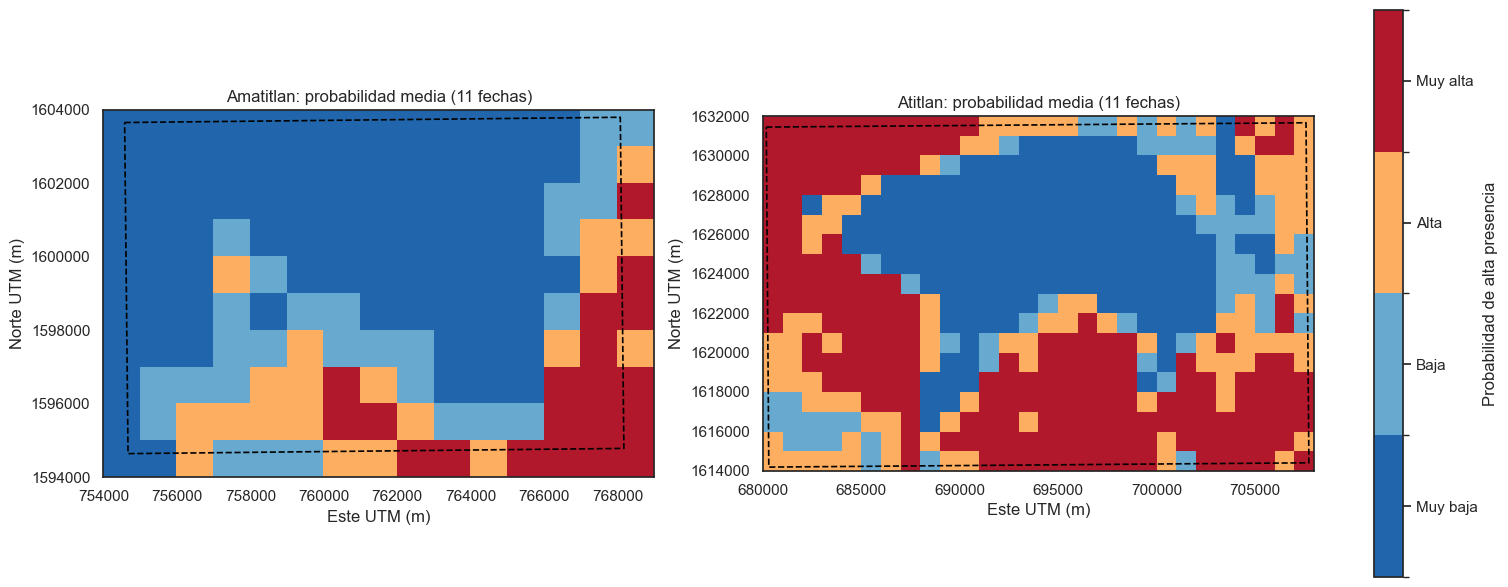

In [4]:
COLORES_PROB = ['#2166ac', '#67a9cf', '#fdae61', '#b2182b']
CMAP_PROB = ListedColormap(COLORES_PROB)
LIMITES_PROB = [0, 0.25, 0.50, 0.75, 1.000001]
NORM_PROB = BoundaryNorm(LIMITES_PROB, CMAP_PROB.N)
ETIQUETAS_PROB = ['Muy baja', 'Baja', 'Alta', 'Muy alta']

def dibujar_grilla(ax, datos, columna, cmap, norm, titulo):
    matriz = (datos.pivot(index='y', columns='x', values=columna)
              .sort_index().sort_index(axis=1))
    xs = matriz.columns.to_numpy(dtype=float)
    ys = matriz.index.to_numpy(dtype=float)
    dx = np.median(np.diff(xs)) if len(xs) > 1 else 1000
    dy = np.median(np.diff(ys)) if len(ys) > 1 else 1000
    imagen = ax.imshow(
        matriz.to_numpy(), origin='lower', interpolation='nearest',
        extent=[xs.min() - dx / 2, xs.max() + dx / 2,
                ys.min() - dy / 2, ys.max() + dy / 2],
        cmap=cmap, norm=norm, aspect='equal'
    )
    lago = datos['lago'].iloc[0]
    referencias[lago].boundary.plot(ax=ax, color='black', linewidth=1.2, linestyle='--')
    ax.set(title=titulo, xlabel='Este UTM (m)', ylabel='Norte UTM (m)')
    ax.ticklabel_format(style='plain', axis='both')
    return imagen

promedio_bloque = (df.groupby(['lago', 'id_bloque', 'x', 'y'], as_index=False)
                   .agg(probabilidad_alta=('probabilidad_alta', 'mean')))
fig, axes = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)
for ax, lago in zip(axes, ['amatitlan', 'atitlan']):
    imagen = dibujar_grilla(
        ax, promedio_bloque[promedio_bloque['lago'] == lago],
        'probabilidad_alta', CMAP_PROB, NORM_PROB,
        f'{lago.title()}: probabilidad media (11 fechas)'
    )
cbar = fig.colorbar(imagen, ax=axes, ticks=[0.125, 0.375, 0.625, 0.875], shrink=0.82)
cbar.ax.set_yticklabels(ETIQUETAS_PROB)
cbar.set_label('Probabilidad de alta presencia')
plt.show()

### Mapas de la fecha más reciente

Para mostrar una situación temporal concreta se utiliza la última adquisición disponible de cada lago: 19 de junio de 2026 en Amatitlán y 22 de julio de 2026 en Atitlán.

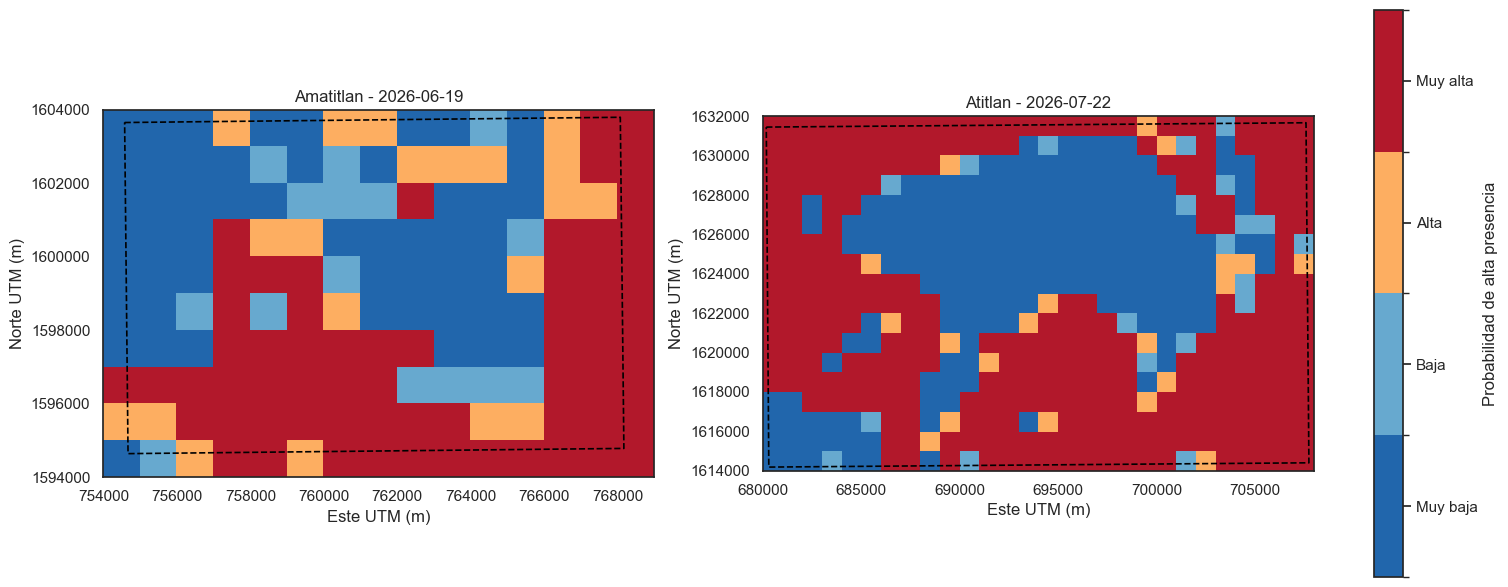

In [5]:
fechas_recientes = df.groupby('lago')['fecha'].max().to_dict()
fig, axes = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)
for ax, lago in zip(axes, ['amatitlan', 'atitlan']):
    fecha = fechas_recientes[lago]
    datos_fecha = df[(df['lago'] == lago) & (df['fecha'] == fecha)]
    imagen = dibujar_grilla(
        ax, datos_fecha, 'probabilidad_alta', CMAP_PROB, NORM_PROB,
        f'{lago.title()} - {fecha.date()}'
    )
cbar = fig.colorbar(imagen, ax=axes, ticks=[0.125, 0.375, 0.625, 0.875], shrink=0.82)
cbar.ax.set_yticklabels(ETIQUETAS_PROB)
cbar.set_label('Probabilidad de alta presencia')
plt.show()

## 9.5. Comparación con los mapas de cianobacteria de la Parte I

La columna `alta_cianobacteria` es la versión binaria del mapa de clorofila-a/NDCI construido en los incisos 1-2. Por ello se compara con la probabilidad modelada para la misma fecha. La comparación evalúa concordancia con la etiqueta satelital derivada, no con mediciones independientes de laboratorio.

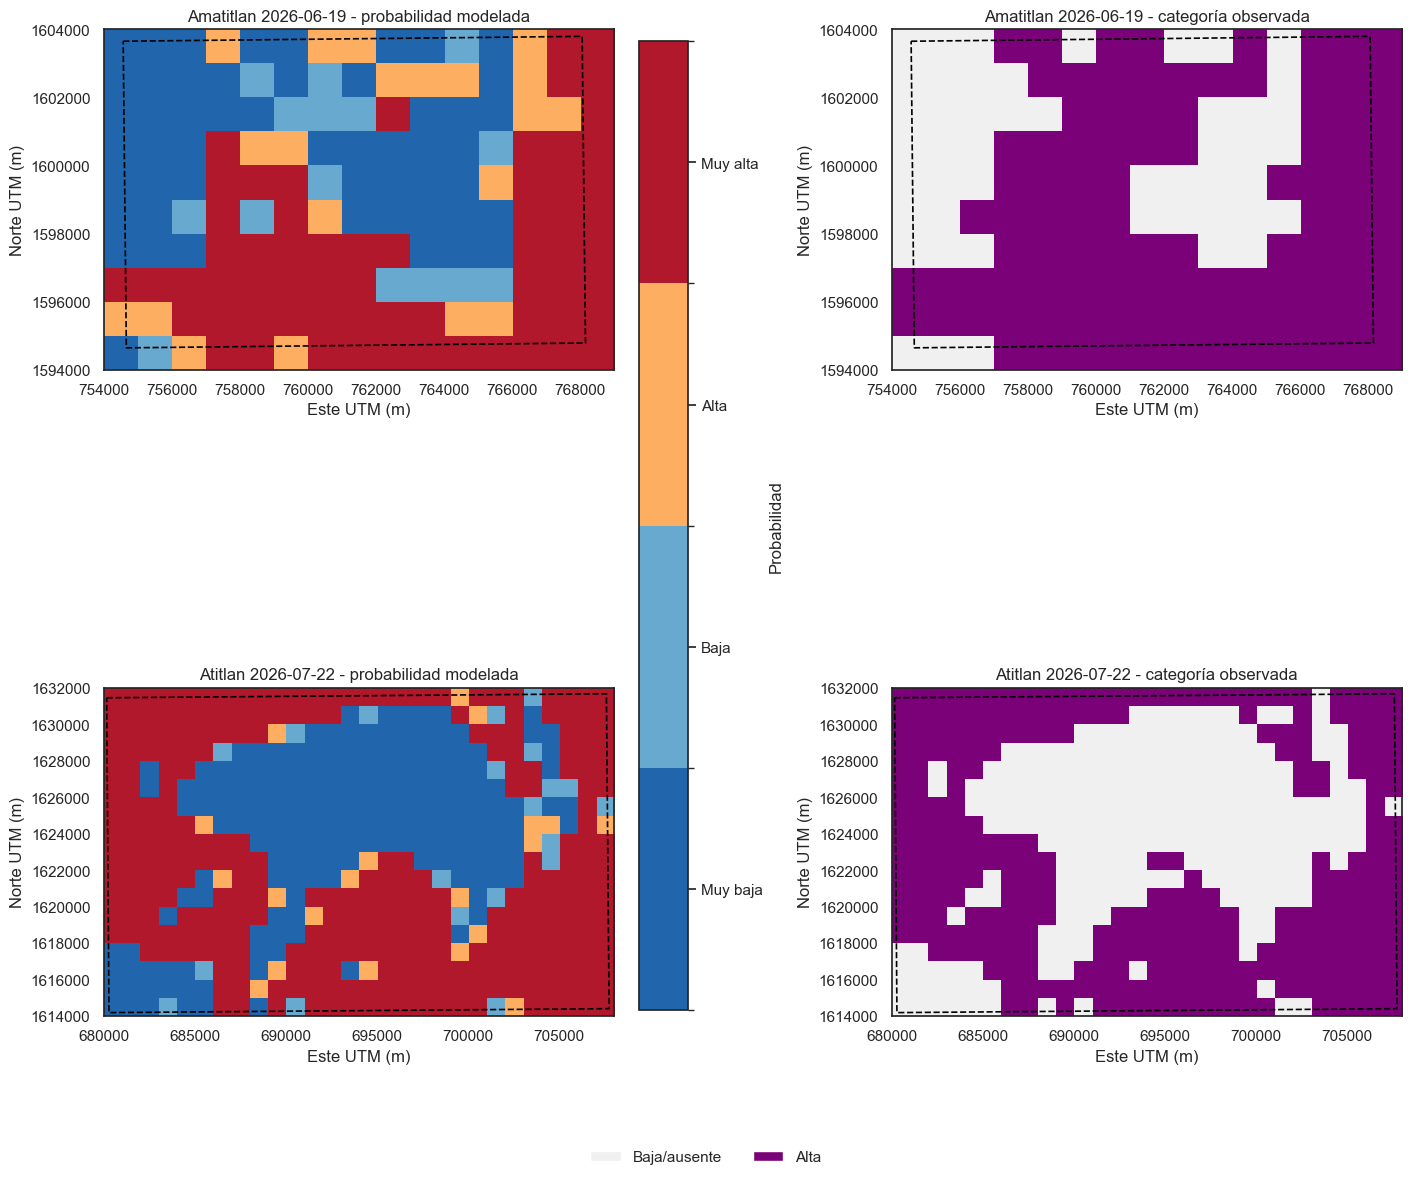

In [6]:
CMAP_BIN = ListedColormap(['#f0f0f0', '#7a0177'])
NORM_BIN = BoundaryNorm([-0.5, 0.5, 1.5], CMAP_BIN.N)

fig, axes = plt.subplots(2, 2, figsize=(14, 13), constrained_layout=True)
for fila, lago in enumerate(['amatitlan', 'atitlan']):
    fecha = fechas_recientes[lago]
    datos_fecha = df[(df['lago'] == lago) & (df['fecha'] == fecha)]
    imagen_prob = dibujar_grilla(
        axes[fila, 0], datos_fecha, 'probabilidad_alta', CMAP_PROB, NORM_PROB,
        f'{lago.title()} {fecha.date()} - probabilidad modelada'
    )
    dibujar_grilla(
        axes[fila, 1], datos_fecha, OBJETIVO, CMAP_BIN, NORM_BIN,
        f'{lago.title()} {fecha.date()} - categoría observada'
    )
cbar = fig.colorbar(imagen_prob, ax=axes[:, 0], ticks=[0.125, 0.375, 0.625, 0.875], shrink=0.75)
cbar.ax.set_yticklabels(ETIQUETAS_PROB)
cbar.set_label('Probabilidad')
fig.legend(handles=[Patch(facecolor='#f0f0f0', label='Baja/ausente'),
                    Patch(facecolor='#7a0177', label='Alta')],
           loc='lower center', ncol=2, frameon=False)
plt.show()

## 9.6. Aciertos, falsos positivos y falsos negativos

Los errores se calculan con predicciones espaciales fuera de muestra. Cada uno de los cinco folds contiene bloques completos que no participaron en el entrenamiento correspondiente. El umbral de clasificación es 0.50.

In [7]:
cv_espacial = GroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
prob_oof = np.full(len(df), np.nan)
fold_oof = np.full(len(df), -1, dtype=int)

for fold, (idx_train, idx_val) in enumerate(cv_espacial.split(X, y, groups=groups), start=1):
    assert set(groups.iloc[idx_train]).isdisjoint(set(groups.iloc[idx_val]))
    modelo_fold = clone(modelo_base).fit(X.iloc[idx_train], y.iloc[idx_train])
    prob_oof[idx_val] = modelo_fold.predict_proba(X.iloc[idx_val])[:, 1]
    fold_oof[idx_val] = fold

assert np.isfinite(prob_oof).all() and (fold_oof > 0).all()
df['probabilidad_oof'] = prob_oof
df['prediccion_oof'] = (prob_oof >= 0.50).astype('int8')
df['fold_espacial'] = fold_oof
df['tipo_resultado'] = np.select(
    [
        (y == 0) & (df['prediccion_oof'] == 0),
        (y == 1) & (df['prediccion_oof'] == 1),
        (y == 0) & (df['prediccion_oof'] == 1),
        (y == 1) & (df['prediccion_oof'] == 0)
    ],
    ['Negativo correcto', 'Positivo correcto', 'Falso positivo', 'Falso negativo'],
    default='Sin clasificar'
)
df['codigo_resultado'] = df['tipo_resultado'].map({
    'Negativo correcto': 0, 'Positivo correcto': 1,
    'Falso positivo': 2, 'Falso negativo': 3
})

def metricas(grupo):
    return pd.Series({
        'Accuracy': accuracy_score(grupo[OBJETIVO], grupo['prediccion_oof']),
        'Precision': precision_score(grupo[OBJETIVO], grupo['prediccion_oof'], zero_division=0),
        'Recall': recall_score(grupo[OBJETIVO], grupo['prediccion_oof'], zero_division=0),
        'F1': f1_score(grupo[OBJETIVO], grupo['prediccion_oof'], zero_division=0),
        'ROC-AUC': roc_auc_score(grupo[OBJETIVO], grupo['probabilidad_oof'])
    })

display(df.groupby('lago').apply(metricas, include_groups=False).round(3))
display(pd.crosstab(df['lago'], df['tipo_resultado'], normalize='index').style.format('{:.1%}'))

,Accuracy,Precision,Recall,F1,ROC-AUC
lago,,,,,
amatitlan,0.857,0.785,0.732,0.758,0.933
atitlan,0.930,0.923,0.942,0.932,0.983


tipo_resultado,Falso negativo,Falso positivo,Negativo correcto,Positivo correcto
lago,,,,
amatitlan,8.2%,6.1%,63.3%,22.4%
atitlan,3.0%,4.0%,44.8%,48.2%


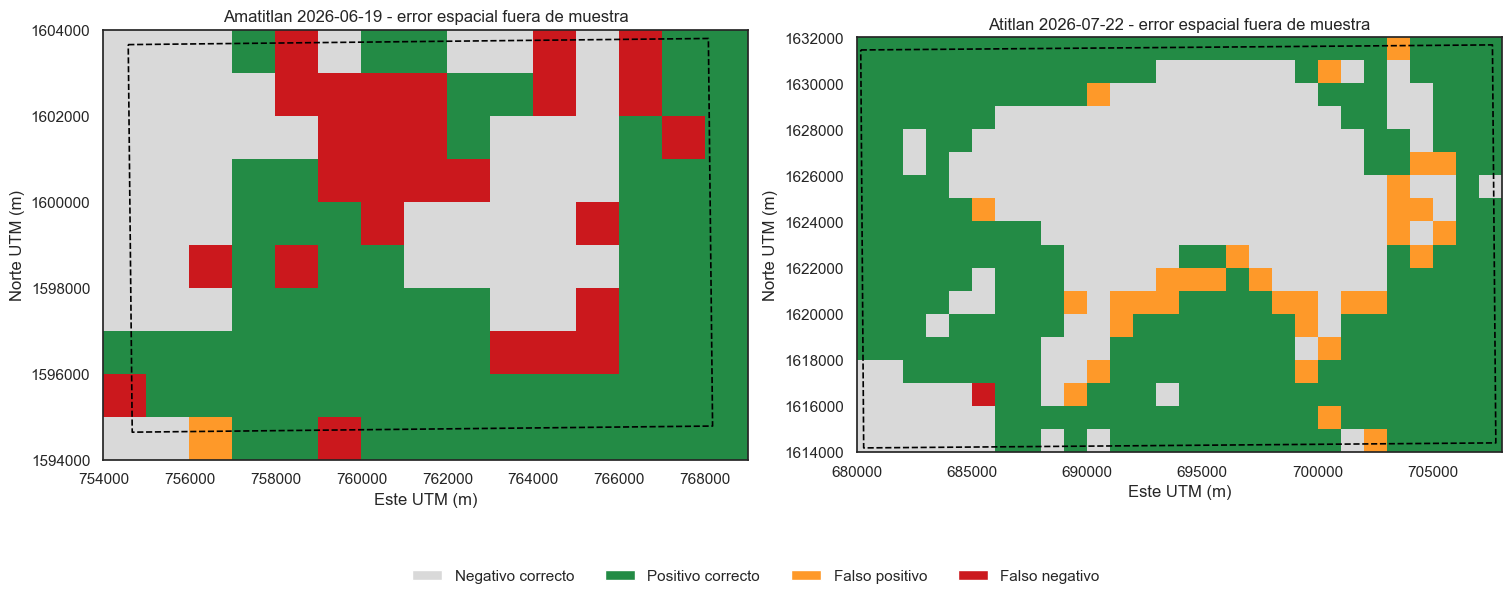

In [8]:
COLORES_ERROR = ['#d9d9d9', '#238b45', '#fe9929', '#cb181d']
CMAP_ERROR = ListedColormap(COLORES_ERROR)
NORM_ERROR = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], CMAP_ERROR.N)
ETIQUETAS_ERROR = ['Negativo correcto', 'Positivo correcto', 'Falso positivo', 'Falso negativo']

fig, axes = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)
for ax, lago in zip(axes, ['amatitlan', 'atitlan']):
    fecha = fechas_recientes[lago]
    datos_fecha = df[(df['lago'] == lago) & (df['fecha'] == fecha)]
    dibujar_grilla(
        ax, datos_fecha, 'codigo_resultado', CMAP_ERROR, NORM_ERROR,
        f'{lago.title()} {fecha.date()} - error espacial fuera de muestra'
    )
fig.legend(handles=[Patch(facecolor=color, label=etiqueta)
                    for color, etiqueta in zip(COLORES_ERROR, ETIQUETAS_ERROR)],
           loc='lower center', ncol=4, frameon=False)
plt.show()

## 9.7. Regiones con dificultad sistemática

Se agrega el error de las 11 fechas por bloque. Una tasa alta indica dificultad repetida y no un fallo aislado de una adquisición. También se comparan cuadrantes relativos dentro de cada área para describir los patrones sin atribuirles causalidad.

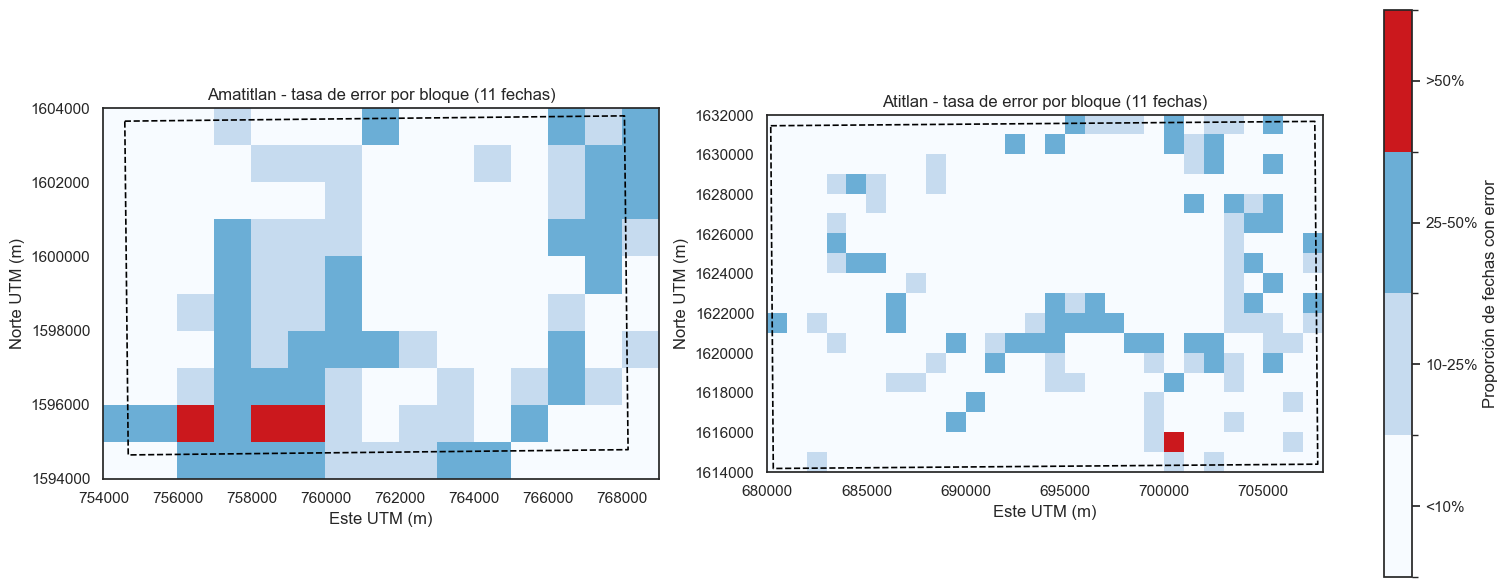

,lago,id_bloque,x,y,observaciones,tasa_error,tasa_fp,tasa_fn,probabilidad_media,frecuencia_alta
0,atitlan,atitlan_1615_700,700500.0,1615500.0,11,0.636,0.636,0.000,0.762,0.273
1,amatitlan,amatitlan_1595_759,759500.0,1595500.0,11,0.545,0.000,0.545,0.546,1.000
2,amatitlan,amatitlan_1595_758,758500.0,1595500.0,11,0.545,0.273,0.273,0.543,0.545
3,amatitlan,amatitlan_1595_756,756500.0,1595500.0,11,0.545,0.545,0.000,0.672,0.455
4,amatitlan,amatitlan_1600_757,757500.0,1600500.0,11,0.455,0.091,0.364,0.438,0.455
5,amatitlan,amatitlan_1597_760,760500.0,1597500.0,11,0.455,0.273,0.182,0.519,0.364
6,amatitlan,amatitlan_1596_759,759500.0,1596500.0,11,0.455,0.364,0.091,0.699,0.636
7,amatitlan,amatitlan_1595_757,757500.0,1595500.0,11,0.455,0.455,0.000,0.684,0.545
8,amatitlan,amatitlan_1596_758,758500.0,1596500.0,11,0.455,0.455,0.000,0.798,0.545
9,atitlan,atitlan_1621_694,694500.0,1621500.0,11,0.455,0.455,0.000,0.644,0.273


In [9]:
df['es_error'] = (df[OBJETIVO] != df['prediccion_oof']).astype('int8')
df['es_fp'] = (df['tipo_resultado'] == 'Falso positivo').astype('int8')
df['es_fn'] = (df['tipo_resultado'] == 'Falso negativo').astype('int8')

dificultad_bloque = (df.groupby(['lago', 'id_bloque', 'x', 'y'], as_index=False)
                     .agg(observaciones=('es_error', 'size'),
                          tasa_error=('es_error', 'mean'),
                          tasa_fp=('es_fp', 'mean'),
                          tasa_fn=('es_fn', 'mean'),
                          probabilidad_media=('probabilidad_oof', 'mean'),
                          frecuencia_alta=(OBJETIVO, 'mean')))

cmap_error_cont = ListedColormap(['#f7fbff', '#c6dbef', '#6baed6', '#cb181d'])
norm_error_cont = BoundaryNorm([0, 0.10, 0.25, 0.50, 1.000001], cmap_error_cont.N)
fig, axes = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)
for ax, lago in zip(axes, ['amatitlan', 'atitlan']):
    imagen = dibujar_grilla(
        ax, dificultad_bloque[dificultad_bloque['lago'] == lago],
        'tasa_error', cmap_error_cont, norm_error_cont,
        f'{lago.title()} - tasa de error por bloque (11 fechas)'
    )
cbar = fig.colorbar(imagen, ax=axes, ticks=[0.05, 0.175, 0.375, 0.75], shrink=0.82)
cbar.ax.set_yticklabels(['<10%', '10-25%', '25-50%', '>50%'])
cbar.set_label('Proporción de fechas con error')
plt.show()

display(dificultad_bloque.sort_values(['tasa_error', 'tasa_fn'], ascending=False)
        .groupby('lago').head(10).reset_index(drop=True).round(3))

In [10]:
def asignar_sector(grupo):
    x_mediana, y_mediana = grupo['x'].median(), grupo['y'].median()
    este_oeste = np.where(grupo['x'] >= x_mediana, 'Este', 'Oeste')
    norte_sur = np.where(grupo['y'] >= y_mediana, 'Norte', 'Sur')
    return pd.Series(np.char.add(np.char.add(norte_sur, '-'), este_oeste), index=grupo.index)

df['sector'] = df.groupby('lago', group_keys=False).apply(asignar_sector, include_groups=False)
resumen_sector = (df.groupby(['lago', 'sector'])
                  .agg(observaciones=('es_error', 'size'),
                       tasa_error=('es_error', 'mean'),
                       tasa_fp=('es_fp', 'mean'),
                       tasa_fn=('es_fn', 'mean'))
                  .reset_index())
display(resumen_sector.style.format({
    'tasa_error': '{:.1%}', 'tasa_fp': '{:.1%}', 'tasa_fn': '{:.1%}'
}))

lineas = ['### Interpretación de los patrones espaciales\n']
for lago in ['amatitlan', 'atitlan']:
    datos_lago = df[df['lago'] == lago]
    peor_sector = (resumen_sector[resumen_sector['lago'] == lago]
                   .sort_values('tasa_error', ascending=False).iloc[0])
    pct_fp = datos_lago['es_fp'].mean()
    pct_fn = datos_lago['es_fn'].mean()
    bloques_repetidos = dificultad_bloque.query('lago == @lago and tasa_error >= 0.50').shape[0]
    unidad_bloque = 'bloque' if bloques_repetidos == 1 else 'bloques'
    lineas.append(
        f'- **{lago.title()}**: el sector relativo con mayor error fue '
        f'**{peor_sector["sector"]}** ({peor_sector["tasa_error"]:.1%}). '
        f'Los falsos positivos representaron {pct_fp:.1%} y los falsos negativos {pct_fn:.1%} '
        f'de las observaciones. Hubo {bloques_repetidos} {unidad_bloque} con errores en al menos la mitad de las fechas.'
    )

lineas.append(
    '\nLos falsos positivos implican activar inspecciones o alertas innecesarias; los falsos negativos '
    'son ambientalmente más graves porque una floración puede permanecer sin atención. Los errores '
    'persistentes pueden aparecer en bloques de borde, píxeles mixtos, zonas con señal óptica atípica '
    'o regiones cuyo patrón difiere del aprendido. Los sectores son descripciones espaciales, no evidencia '
    'de un mecanismo causal. Deben contrastarse con profundidad, corrientes, tributarios, descargas, viento '
    'y muestreos in situ.'
)
display(Markdown('\n'.join(lineas)))

,lago,sector,observaciones,tasa_error,tasa_fp,tasa_fn
0,amatitlan,Norte-Este,440,12.5%,4.3%,8.2%
1,amatitlan,Norte-Oeste,385,8.8%,2.3%,6.5%
2,amatitlan,Sur-Este,440,12.0%,6.4%,5.7%
3,amatitlan,Sur-Oeste,385,24.4%,11.7%,12.7%
4,atitlan,Norte-Este,1386,7.7%,2.2%,5.6%
5,atitlan,Norte-Oeste,1386,3.8%,2.5%,1.4%
6,atitlan,Sur-Este,1386,10.2%,7.1%,3.0%
7,atitlan,Sur-Oeste,1386,6.3%,4.3%,2.0%


### Interpretación de los patrones espaciales

- **Amatitlan**: el sector relativo con mayor error fue **Sur-Oeste** (24.4%). Los falsos positivos representaron 6.1% y los falsos negativos 8.2% de las observaciones. Hubo 3 bloques con errores en al menos la mitad de las fechas.
- **Atitlan**: el sector relativo con mayor error fue **Sur-Este** (10.2%). Los falsos positivos representaron 4.0% y los falsos negativos 3.0% de las observaciones. Hubo 1 bloque con errores en al menos la mitad de las fechas.

Los falsos positivos implican activar inspecciones o alertas innecesarias; los falsos negativos son ambientalmente más graves porque una floración puede permanecer sin atención. Los errores persistentes pueden aparecer en bloques de borde, píxeles mixtos, zonas con señal óptica atípica o regiones cuyo patrón difiere del aprendido. Los sectores son descripciones espaciales, no evidencia de un mecanismo causal. Deben contrastarse con profundidad, corrientes, tributarios, descargas, viento y muestreos in situ.

## Conclusiones del inciso 9

Los mapas convierten la salida del clasificador en un producto espacial comparable entre lagos y fechas. La probabilidad conserva más información que una clase binaria y permite priorizar zonas muy altas sin ocultar áreas cercanas al umbral. La comparación espacial fuera de muestra es indispensable: los mapas del modelo final sirven para predicción, mientras los mapas OOF describen de forma más honesta dónde falla.

La principal limitación cartográfica es que las referencias disponibles son rectángulos de adquisición, no límites detallados de los lagos. Además, la etiqueta es una transformación de índices Sentinel-2 y no verdad de campo. Antes de utilizar estos mapas para decisiones ambientales se requiere una máscara hidrográfica precisa, validación con muestras de clorofila-a/cianobacterias y calibración del umbral según el costo aceptable de falsos negativos.